In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

import os


In [3]:
ll_df = pd.read_csv("data/results.csv")

In [4]:
ll_df.head()

,sample,theta,beta_out,sigma,bEP,bCP,delta,muEI,muIR,muRS,...,S_0,E_0,I_0,R_0,sig_obs,loglik,loglik.se,flag,file_id,ll_lowIQ
0,15,41.061660,0.007761,0.122382,0.002152,-0.065062,0.016667,17.994218,37.598865,3.635296,...,0.831716,0.008274,0.005189,0.154822,0.052191,-2134.012940,0.797904,1,3060,-2134.551126
1,2,32.995885,0.003438,0.111727,0.068342,-0.138298,0.016667,20.014308,29.000449,2.673761,...,0.854101,0.006532,0.003889,0.135477,0.082106,-2135.190923,1.823573,1,2687,-2136.420923
2,16,41.375689,0.003259,0.104098,-0.081361,-0.112962,0.016667,19.355653,37.711776,2.395466,...,0.801291,0.006596,0.001953,0.190159,0.055448,-2135.777750,0.640306,1,2814,-2136.209637
3,14,49.659714,0.009522,0.117566,-0.034316,-0.106148,0.016667,18.085087,46.433266,3.627906,...,0.838603,0.009236,0.004963,0.147197,0.077193,-2135.925445,1.408073,1,3073,-2136.875190
4,16,30.920848,0.007446,0.119109,-0.016401,-0.063950,0.016667,19.376104,28.700210,3.098439,...,0.848426,0.004741,0.004731,0.142102,0.057500,-2136.111105,0.759784,1,2772,-2136.623579


/var/folders/20/x0sn0k_10hqfn739thwg8lxw0000gn/T/ipykernel_49283/2207352927.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(-1.0, 3.0)

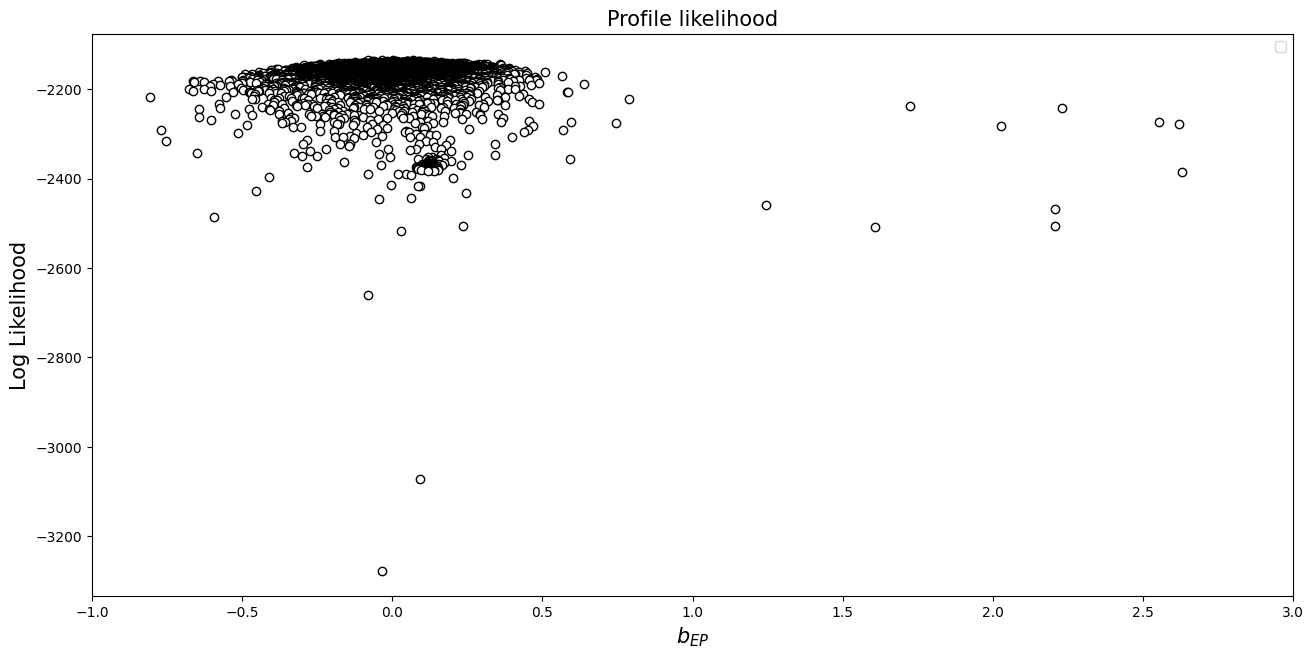

In [ ]:
import seaborn as sns

param_arr = ll_df["bEP"]
ll_arr    = ll_df["loglik"]

fig, ax = plt.subplots(1, 1, figsize=(15.5, 7.3))

ax.scatter(param_arr, ll_arr, edgecolor="k", facecolor="white")
ax.set_xlabel(r"$b_{EP}$", fontsize=15)
ax.set_ylabel("Log Likelihood", fontsize=15)
ax.set_title("Profile likelihood", fontsize=15)
ax.legend()

ax.set_xlim([-1, 3.0])

In [85]:
from statsmodels.formula.api import wls
import statsmodels.api as sm

from scipy.stats import chi2 as qchisq

from scipy import linalg
from math import ceil
import numpy as np


def mcap_loglikelihood(loglik_values, param_search, confidence=0.95, lambda_sm=0.9, n_grid=1000):
    df_data       = pd.DataFrame(columns=["lp", "b", "a"])
    df_data["lp"] = loglik_values
    df_data["b"]  = param_search
    df_data["a"]  = param_search**2

    lowess_sm  = sm.nonparametric.lowess
    param_grid =  np.linspace(min(param_search), max(param_search), n_grid)
    loglik_sm  = lowess_sm(loglik_values, param_search, frac=1-lambda_sm, it=3, return_sorted = False, xvals=param_grid)

    arg_max   = np.argmax(loglik_sm)

    disttance = abs(param_search-param_grid[arg_max])

    #included <- dist < sort(dist)[trunc(lambda*length(dist))]

    max_dist  = np.max(disttance)

    weights = np.full( len(param_search), np.nan)
    weights = (1-(disttance/max_dist)**3)**3
    weights = {param_search[idx_p]: weights[idx_p] for idx_p in range(weights.shape[0])}
    #weights[included] <- (1-(dist[included]/maxdist)^3)^3

    df_data["weights"] = df_data["b"].replace(weights)

    model = wls(formula = 'lp ~ a + b', data = df_data, weights=df_data["weights"].values).fit()

    b      = model.params["b"]
    a      = model.params["a"]

    var_a  = model.cov_params().loc["a"]["a"]
    var_b  = model.cov_params().loc["a"]["a"]
    cov_ab = model.cov_params().loc["a"]["b"]

    se_mc_squared    = (1 / (4 * a**2)) * (var_b - (2 * b/a) * cov_ab + (b**2 / a**2) * var_a)
    se_stat_squared  = 1/(2*a)
    se_total_squared = se_mc_squared + se_stat_squared
    loglik_diff      = max(loglik_sm) -  loglik_sm

    delta            = qchisq.ppf(confidence, 1) * (a * se_mc_squared + 0.5)
    #delta            = qchisq.ppf(confidence, 1) * (a * se_total_squared + 0.5)

    ci               = param_grid[np.where(loglik_diff < delta)]
    if ci.shape[0]>0:
        ci_low           = ci[0]
        ci_high          = ci[-1]
    else:
        ci_low           = None
        ci_high          = None

    confidence = int(confidence*100)
    df_param_resume                       = pd.DataFrame(columns=["mle", "delta", f"{confidence}_high", f"{confidence}_low"])
    df_param_resume["mle"]                = [param_grid[arg_max]]
    df_param_resume["delta"]              = [delta]
    df_param_resume[f"{confidence}_high"] = [ci_high]
    df_param_resume[f"{confidence}_low"]  = [ci_low]

    df_resume                  = pd.DataFrame(columns=["parameter", "loglik_smooth", "quadratic"])
    df_resume["parameter"]     = param_grid
    df_resume["loglik_smooth"] = loglik_sm
    df_resume["quadratic"]     = a * param_grid**2 + b * param_grid + model.params["Intercept"]

    return df_resume, df_param_resume

/var/folders/20/x0sn0k_10hqfn739thwg8lxw0000gn/T/ipykernel_49283/3362895821.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


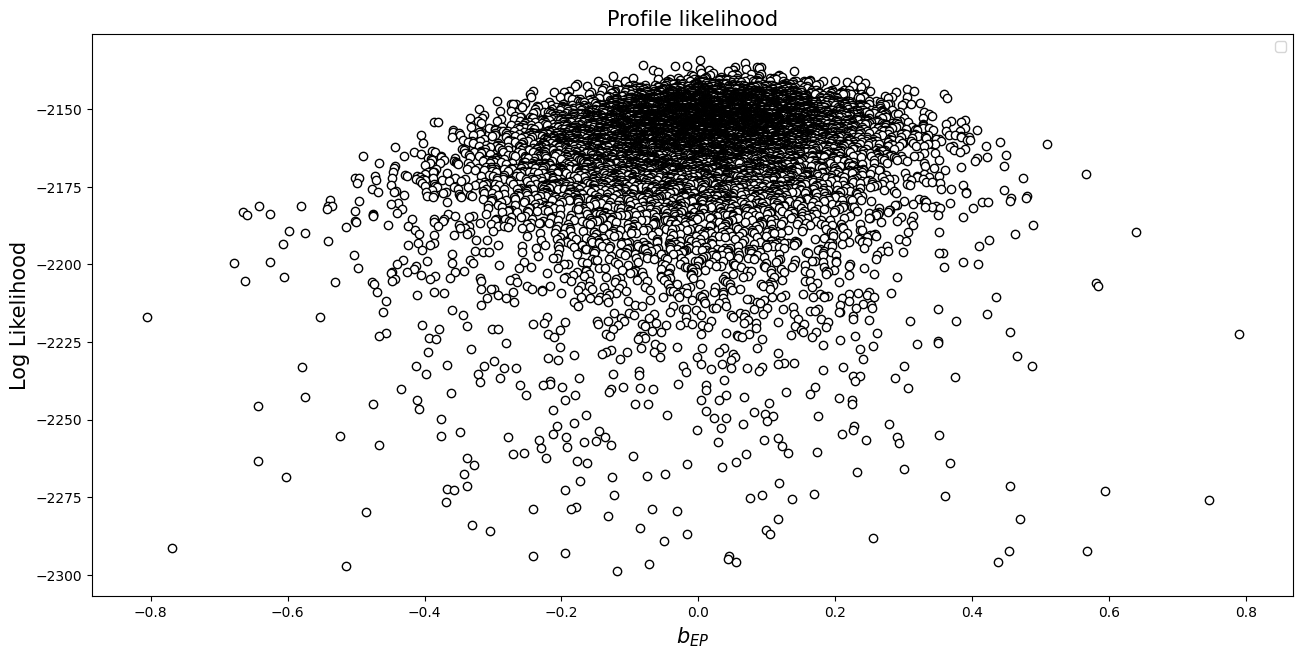

In [86]:
ll_sm_df  = ll_df[ll_df.bEP.between(-1, 1)]
ll_sm_df = ll_sm_df[ll_sm_df.loglik > -2300]
param_arr = ll_sm_df["bEP"]
ll_arr    = ll_sm_df["loglik"]

fig, ax = plt.subplots(1, 1, figsize=(15.5, 7.3))

ax.scatter(param_arr, ll_arr, edgecolor="k", facecolor="white")
ax.set_xlabel(r"$b_{EP}$", fontsize=15)
ax.set_ylabel("Log Likelihood", fontsize=15)
ax.set_title("Profile likelihood", fontsize=15)
ax.legend()

In [ ]:
ll_sm_df = ll_df[ll_df.bEP.between(-0.5, 1)]
ll_sm_df = ll_sm_df[ll_sm_df.loglik > -2300]

param_arr = ll_sm_df["bEP"].values
ll_arr    = ll_sm_df["loglik"].values

p_df, ci_df = mcap_loglikelihood(ll_arr, param_arr, confidence=0.95, lambda_sm=0.75, n_grid=1000)
ci_df

,mle,delta,95_high,95_low
0,0.071772,1.639136,0.171131,-0.067589


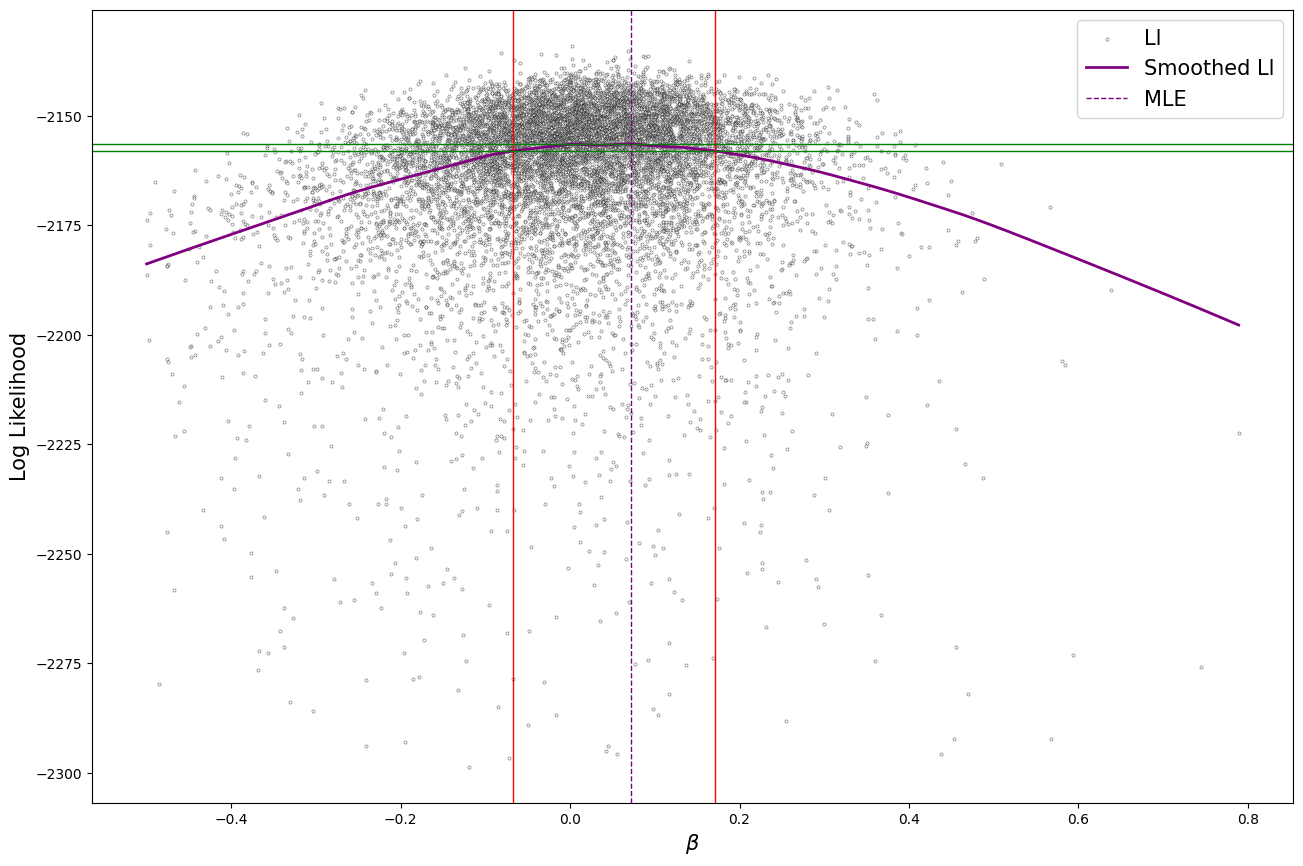

In [88]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(15.5, 10.3))


ax.scatter(param_arr, ll_arr, edgecolor="k", facecolor="white", label="Ll", s=5, alpha=0.5, lw=0.5)

ax.plot(p_df.parameter, p_df.loglik_smooth, color="purple", label = "Smoothed Ll", lw=2)
#ax.plot(p_df.parameter, p_df.quadratic, color="blue", label = "Quadratic", lw=2)

ax.axvline(x=ci_df["95_high"].values, color="red", linestyle="-", lw=1)
ax.axvline(x=ci_df["95_low"].values,  color="red", linestyle="-", lw=1)
ax.axhline(y=max(p_df.loglik_smooth), color="green", linestyle="-", lw=1)
ax.axhline(y=max(p_df.loglik_smooth) - ci_df["delta"].values, color="green", linestyle="-", lw=1)

#ax.axvline(x=beta_truth, color="red", linestyle="--", lw=1, label="Truth")
ax.axvline(x=ci_df["mle"].values, color="purple", linestyle="--", lw=1, label="MLE")

ax.set_xlabel(r"$\beta$", fontsize=15)
ax.set_ylabel("Log Likelihood", fontsize=15)
ax.legend(fontsize=15)


In [89]:
gamma_df, gamma_ci_df = mcap_loglikelihood(loglik_df.value, loglik_df.gamma, confidence=0.95, lambda_sm=0.5, n_grid=1000)
gamma_df


NameError: name 'loglik_df' is not defined